Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import joblib
import warnings
warnings.filterwarnings('ignore')

Load Data

In [3]:
train_df = pd.read_csv('../data/train_motion_data.csv')
test_df = pd.read_csv('../data/test_motion_data.csv')

print("Training Data Shape:", train_df.shape)
print("Testing Data Shape:", test_df.shape)
train_df.head()

Training Data Shape: (3644, 8)
Testing Data Shape: (3084, 8)


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Class,Timestamp
0,0.000000,0.000000,0.000000,0.059407,-0.174707,0.101938,NORMAL,3581629
1,-1.624864,-1.082492,-0.204183,-0.028558,0.051313,0.135536,NORMAL,3581630
2,-0.594660,-0.122410,0.220502,-0.019395,-0.029322,0.087888,NORMAL,3581630
3,0.738478,-0.228456,0.667732,0.069791,-0.029932,0.054902,NORMAL,3581631
4,0.101741,0.777568,-0.066730,0.030696,-0.003665,0.054902,NORMAL,3581631


Exploratory Data Analysis

Missing values: 
 AccX         0
AccY         0
AccZ         0
GyroX        0
GyroY        0
GyroZ        0
Class        0
Timestamp    0
dtype: int64


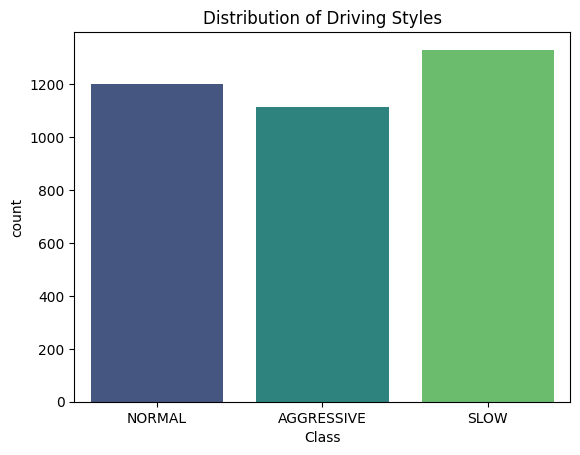

              AccX         AccY         AccZ        GyroX        GyroY  \
count  3644.000000  3644.000000  3644.000000  3644.000000  3644.000000   
mean      0.040467    -0.073418     0.008271     0.001593    -0.001273   
std       0.985653     0.903408     0.985061     0.066918     0.126205   
min      -4.636523    -4.699795    -7.143998    -0.751822    -1.587028   
25%      -0.550695    -0.592540    -0.558464    -0.028558    -0.053756   
50%       0.003931    -0.080833     0.002262     0.001985    -0.001833   
75%       0.595987     0.452401     0.556157     0.031918     0.051313   
max       4.985548     4.245151     5.171739     0.849255     1.679879   

             GyroZ     Timestamp  
count  3644.000000  3.644000e+03  
mean      0.007949  3.582707e+06  
std       0.115687  6.421479e+02  
min      -1.236468  3.581629e+06  
25%      -0.029398  3.582121e+06  
50%       0.002978  3.582702e+06  
75%       0.040852  3.583270e+06  
max       1.190500  3.583791e+06  


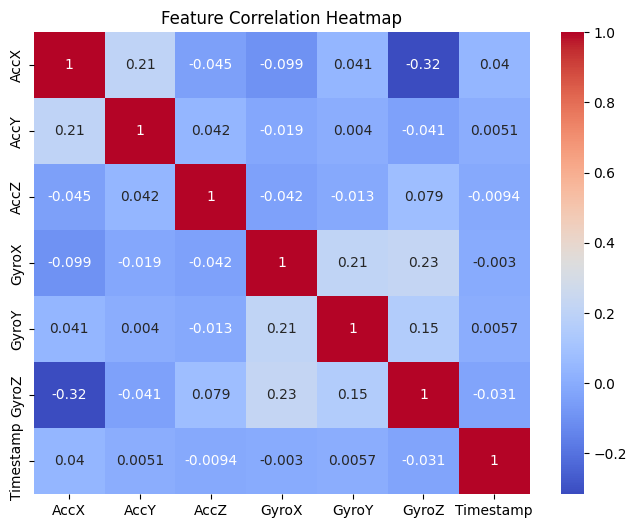

In [6]:
# Check for missing values
print("Missing values: \n", train_df.isnull().sum())

# Target Distribution
sns.countplot(x='Class', data=train_df, palette='viridis')
plt.title('Distribution of Driving Styles')
plt.show()

# Summary Statistics
print(train_df.describe())

# Correlation heatmap (use only numeric columns to avoid string -> float errors)
plt.figure(figsize=(8, 6))
numeric_df = train_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

Preprocessing

In [7]:
# Encode target labels
label_encoder = LabelEncoder()
train_df['Class_encoded'] = label_encoder.fit_transform(train_df['Class'])

# Feature and target split
X = train_df.drop(columns=['Class', 'Class_encoded', 'Timestamp'])
y = train_df['Class_encoded']

# Split for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Ensure test features match training features: drop Timestamp and Class if present,
# then reorder columns to match X (training feature order) before transforming.
test_features = test_df.drop(columns=['Timestamp', 'Class'], errors='ignore')
test_features = test_features[X.columns]
test_scaled = scaler.transform(test_features)

print("Data preprocessing complete.")

Data preprocessing complete.


Model Training and Evaluation

In [8]:
def evaluate_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    print("\nClassification Report:\n", classification_report(y_val, y_pred))
    print("Accuracy:", accuracy_score(y_val, y_pred))
    print("Precision:", precision_score(y_val, y_pred, average='weighted'))
    print("Recall:", recall_score(y_val, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_val, y_pred, average='weighted'))
    
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model.__class__.__name__}')
    plt.show()

Try Baseline Models

Evaluating Logistic Regression...

Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.20      0.28       223
           1       0.24      0.04      0.06       240
           2       0.37      0.83      0.51       266

    accuracy                           0.38       729
   macro avg       0.36      0.36      0.29       729
weighted avg       0.36      0.38      0.29       729

Accuracy: 0.3772290809327846
Precision: 0.3581727193394318
Recall: 0.3772290809327846
F1 Score: 0.2949893106269107


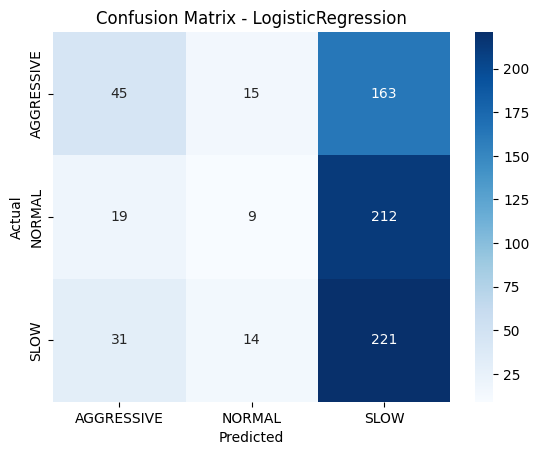

Evaluating Random Forest...

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.44      0.47       223
           1       0.40      0.39      0.39       240
           2       0.43      0.48      0.45       266

    accuracy                           0.44       729
   macro avg       0.45      0.44      0.44       729
weighted avg       0.44      0.44      0.44       729

Accuracy: 0.4403292181069959
Precision: 0.44313441518907654
Recall: 0.4403292181069959
F1 Score: 0.4405690213233145


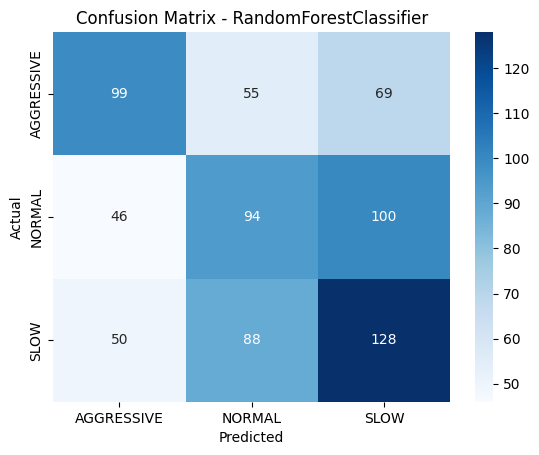

Evaluating Support Vector Machine...

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.37      0.45       223
           1       0.31      0.14      0.19       240
           2       0.41      0.75      0.53       266

    accuracy                           0.43       729
   macro avg       0.44      0.42      0.39       729
weighted avg       0.44      0.43      0.40       729

Accuracy: 0.43209876543209874
Precision: 0.43539209654528765
Recall: 0.43209876543209874
F1 Score: 0.3960355067280731


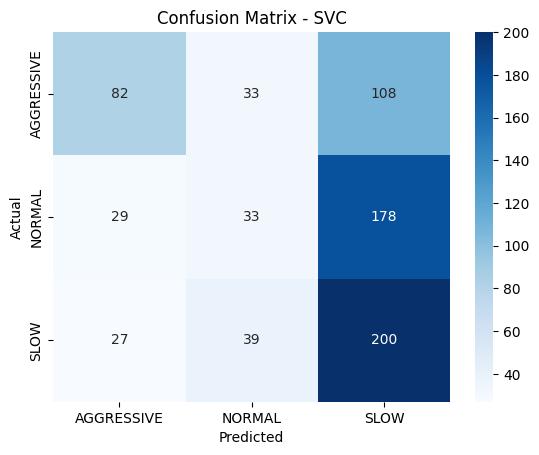

Evaluating XGBoost...

Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.37      0.41       223
           1       0.37      0.37      0.37       240
           2       0.40      0.46      0.43       266

    accuracy                           0.40       729
   macro avg       0.41      0.40      0.40       729
weighted avg       0.41      0.40      0.40       729

Accuracy: 0.40329218106995884
Precision: 0.4069820374167829
Recall: 0.40329218106995884
F1 Score: 0.40284379591428576


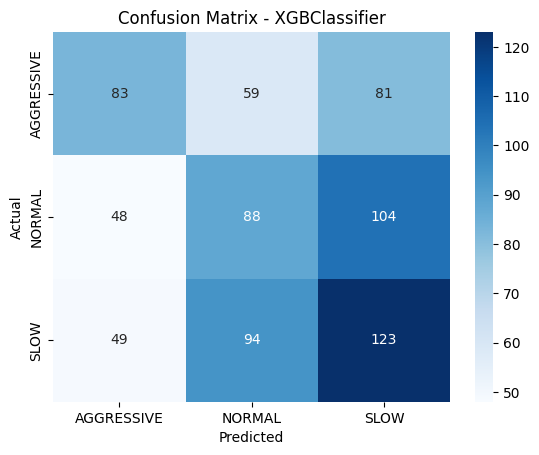

In [9]:
# Logistic Regression
print("Evaluating Logistic Regression...")
evaluate_model(LogisticRegression(max_iter=500), X_train_scaled, y_train, X_val_scaled, y_val)

# Random Forest
print("Evaluating Random Forest...")
evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42), X_train_scaled, y_train, X_val_scaled, y_val)

# Support Vector Machine
print("Evaluating Support Vector Machine...")
evaluate_model(SVC(kernel='rbf', C=1, gamma='scale'), X_train_scaled, y_train, X_val_scaled, y_val)

# XGBoost
print("Evaluating XGBoost...")
evaluate_model(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42), X_train_scaled, y_train, X_val_scaled, y_val)

Hyperparameter Tuning

Tuning Logistic Regression...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters for Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Tuning Random Forest...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters for Random Forest: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Tuning Support Vector Machine...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters for Support Vector Machine: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Tuning XGBoost...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters for XGBoost: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Tuned Model Comparison:
                     Model  CV F1 (weighted)  \
3                 XGBoost          0.423042   
1           Random Forest          0.413493   
2  Support Vector Machine          0.402695   
0     Logistic Regression          0.316664   

   

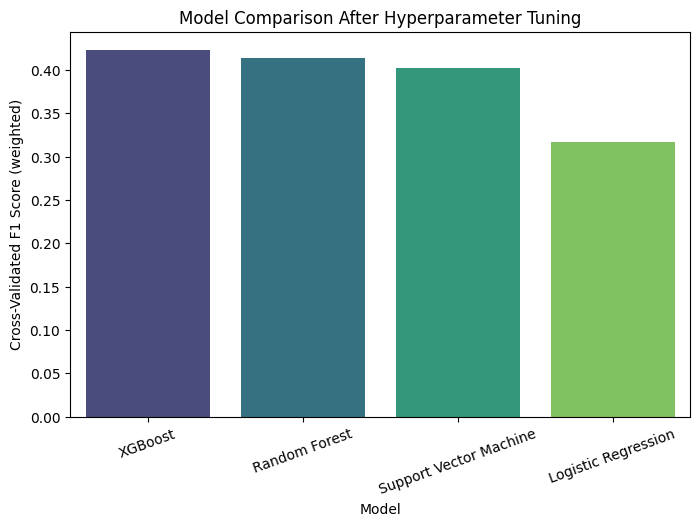

Best model after tuning: XGBoost

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.38      0.44       223
           1       0.36      0.34      0.35       240
           2       0.41      0.54      0.47       266

    accuracy                           0.42       729
   macro avg       0.44      0.42      0.42       729
weighted avg       0.43      0.42      0.42       729

Accuracy: 0.42386831275720166
Precision: 0.433303307619719
Recall: 0.42386831275720166
F1 Score: 0.421196716702055


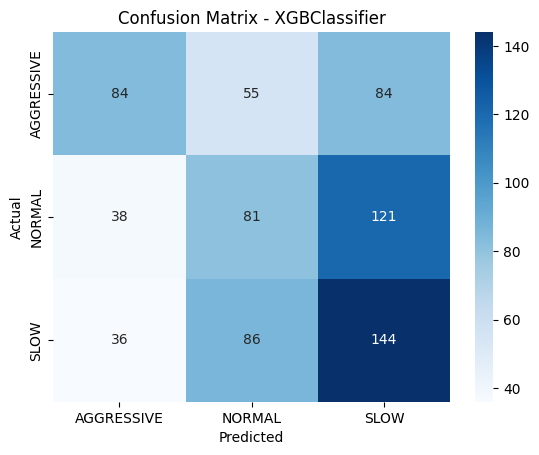

In [10]:
tuned_models = {}
results_summary = []

# Logistic Regression
print("Tuning Logistic Regression...")
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}
lr = LogisticRegression(max_iter=500, random_state=42)
grid_lr = GridSearchCV(lr, param_grid_lr, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_lr.fit(X_train_scaled, y_train)

tuned_models['Logistic Regression'] = grid_lr.best_estimator_
results_summary.append(['Logistic Regression', grid_lr.best_score_, grid_lr.best_params_])
print("Best parameters for Logistic Regression:", grid_lr.best_params_)

# Random Forest
print("Tuning Random Forest...")
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_rf.fit(X_train_scaled, y_train)

tuned_models['Random Forest'] = grid_rf.best_estimator_
results_summary.append(['Random Forest', grid_rf.best_score_, grid_rf.best_params_])
print("Best parameters for Random Forest:", grid_rf.best_params_)

# Support Vector Machine
print("Tuning Support Vector Machine...")
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'poly']
}
svm_model = SVC(probability=True, random_state=42)
grid_svm = GridSearchCV(svm_model, param_grid_svm, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_svm.fit(X_train_scaled, y_train)

tuned_models['Support Vector Machine'] = grid_svm.best_estimator_
results_summary.append(['Support Vector Machine', grid_svm.best_score_, grid_svm.best_params_])
print("Best parameters for Support Vector Machine:", grid_svm.best_params_)

# XGBoost
print("Tuning XGBoost...")
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_xgb.fit(X_train_scaled, y_train)

tuned_models['XGBoost'] = grid_xgb.best_estimator_
results_summary.append(['XGBoost', grid_xgb.best_score_, grid_xgb.best_params_])
print("Best parameters for XGBoost:", grid_xgb.best_params_)

# Compare tuned model results
results_df = pd.DataFrame(results_summary, columns=['Model', 'CV F1 (weighted)', 'Best Params'])
results_df = results_df.sort_values(by='CV F1 (weighted)', ascending=False)
print("\nTuned Model Comparison:\n", results_df)

# Plot comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='CV F1 (weighted)', data=results_df, palette='viridis')
plt.title('Model Comparison After Hyperparameter Tuning')
plt.ylabel('Cross-Validated F1 Score (weighted)')
plt.xticks(rotation=20)
plt.show()

best_model_name = results_df.iloc[0]['Model']
best_model = tuned_models[best_model_name]
print(f"Best model after tuning: {best_model_name}")
evaluate_model(best_model, X_train_scaled, y_train, X_val_scaled, y_val)

Predict on Test Data

In [12]:
# Predict with best model
test_predictions = best_model.predict(test_scaled)
test_labels = label_encoder.inverse_transform(test_predictions)

# Save predictions
submission = pd.DataFrame({'timestamp': test_df['Timestamp'], 'predicted_driving_style': test_labels})
submission.to_csv('test_predictions.csv', index=False)
print("Predictions saved to test_predictions.csv")

# Save model and scaler
joblib.dump(best_model, 'best_driving_behavior_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
print("Model, scaler, and label encoder saved.")



Predictions saved to test_predictions.csv
Model, scaler, and label encoder saved.
